# 20-Year AAA Bond VAR vs 10-Year Treasury VAR

Compare the baseline System 1 VAR (10-year GSW Treasury) with an alternative
using Moody's AAA 20-year corporate bond yields.

**Annual holding-period return** (zero-coupon approximation):
- 10yr: $r^{10} = 10 \cdot y^{10}_{t-1}/100 - 9 \cdot y^{10}_{t}/100$
- 20yr: $r^{20} = 20 \cdot y^{AAA}_{t-1}/100 - 19 \cdot y^{AAA}_{t}/100$

Everything at **annual frequency**, sample from **1950 onward**.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR = Path("data/Thesisdata")

# ── AAA yields (monthly → end-of-year) ──
aaa = pd.read_csv(DATA_DIR / "AAA.csv", index_col="observation_date", parse_dates=True)
aaa.index = aaa.index.to_period("M").to_timestamp("M")
aaa_annual = aaa.resample("YE-DEC").last()
aaa_annual.index = aaa_annual.index.year
print(f"AAA annual: {aaa_annual.index[0]}–{aaa_annual.index[-1]}  ({len(aaa_annual)} years)")

# ── Baseline dataset (already at annual frequency) ──
baseline = pd.read_csv("data/var_dataset.csv", index_col="year")
print(f"Baseline:   {baseline.index[0]}–{baseline.index[-1]}  ({len(baseline)} years)")
print(f"Columns:    {list(baseline.columns)}")

AAA annual: 1919–2026  (108 years)
Baseline:   1962–2025  (64 years)
Columns:    ['rtb', 'xr', 'xb', 'y_nom', 'dp']


## 2. Construct 20-Year AAA Bond Returns (Annual)

Annual holding-period return on a 20-year zero-coupon bond:

$$r^{20}_t = 20 \cdot y^{AAA}_{t-1}/100 \;-\; 19 \cdot y^{AAA}_{t}/100$$

Need $r_{bill}$ for excess return. Back it out from existing data: the baseline has quarterly-summed returns, but we need a consistent nominal bill return at annual frequency. Reconstruct from TB3MS and CPI.

In [2]:
# ── Construct nominal bill return at annual frequency ──
# r_bill_q = TB3MS_{t-1}/400  →  sum 4 quarters per year
tbill = pd.read_csv(DATA_DIR / "TB3MS.csv", index_col="observation_date", parse_dates=True)
tbill.index = tbill.index.to_period("M").to_timestamp("M")
tbill_q = tbill.resample("QE-DEC").last()
r_bill_q = tbill_q["TB3MS"].shift(1) / 400   # lagged one quarter
r_bill_q_clean = r_bill_q.dropna()
r_bill_q_clean_yr = r_bill_q_clean.copy()
r_bill_q_clean_yr.index = r_bill_q_clean_yr.index.year

# Sum 4 quarterly log bill returns per year (keep only complete years)
r_bill_annual = r_bill_q_clean.groupby(r_bill_q_clean.index.year).agg(['sum', 'count'])
r_bill_annual = r_bill_annual[r_bill_annual['count'] == 4]['sum']
r_bill_annual.index.name = "year"

# ── Construct 20yr AAA bond return (annual) ──
y_aaa = aaa_annual["AAA"]
r_bond_20 = 20 * y_aaa.shift(1) / 100 - 19 * y_aaa / 100
xb_20 = r_bond_20 - r_bill_annual
y_aaa_dec = y_aaa / 100  # yield in decimal

# ── Also reconstruct 10yr bond return the same way for apples-to-apples ──
# (the baseline xb used quarterly GSW yields; let's also do a simple annual version)

# ── Build alternative dataset: replace xb → xb_20, y_nom → y_aaa ──
alt = baseline.copy()
common = alt.index.intersection(xb_20.dropna().index).intersection(y_aaa_dec.dropna().index)
alt = alt.loc[common]
alt["xb"] = xb_20.loc[common]
alt["y_nom"] = y_aaa_dec.loc[common]

# Trim to post-war (1950+)
alt = alt.loc[alt.index >= 1950]
base_trim = baseline.loc[baseline.index.isin(alt.index)]

print(f"Alternative dataset: {alt.index[0]}–{alt.index[-1]}  ({len(alt)} years)")
print(f"Baseline (trimmed):  {base_trim.index[0]}–{base_trim.index[-1]}  ({len(base_trim)} years)")
print(f"\nAlternative summary:")
display(alt.describe().round(6))

Alternative dataset: 1962–2025  (64 years)
Baseline (trimmed):  1962–2025  (64 years)

Alternative summary:


,rtb,xr,xb,y_nom,dp
count,64.000000,64.000000,64.000000,64.000000,64.000000
mean,0.006973,0.054920,0.020979,0.068006,-3.670204
std,0.025641,0.162447,0.182551,0.026561,0.435889
min,-0.068787,-0.517381,-0.473350,0.022600,-4.456437
25%,-0.008325,-0.036725,-0.082344,0.047250,-4.006443
50%,0.009067,0.108043,0.022088,0.066050,-3.585948
75%,0.019833,0.158164,0.124800,0.083475,-3.344758
max,0.072256,0.269855,0.488500,0.142300,-2.924803


## 3. Compare Yield and Return Series

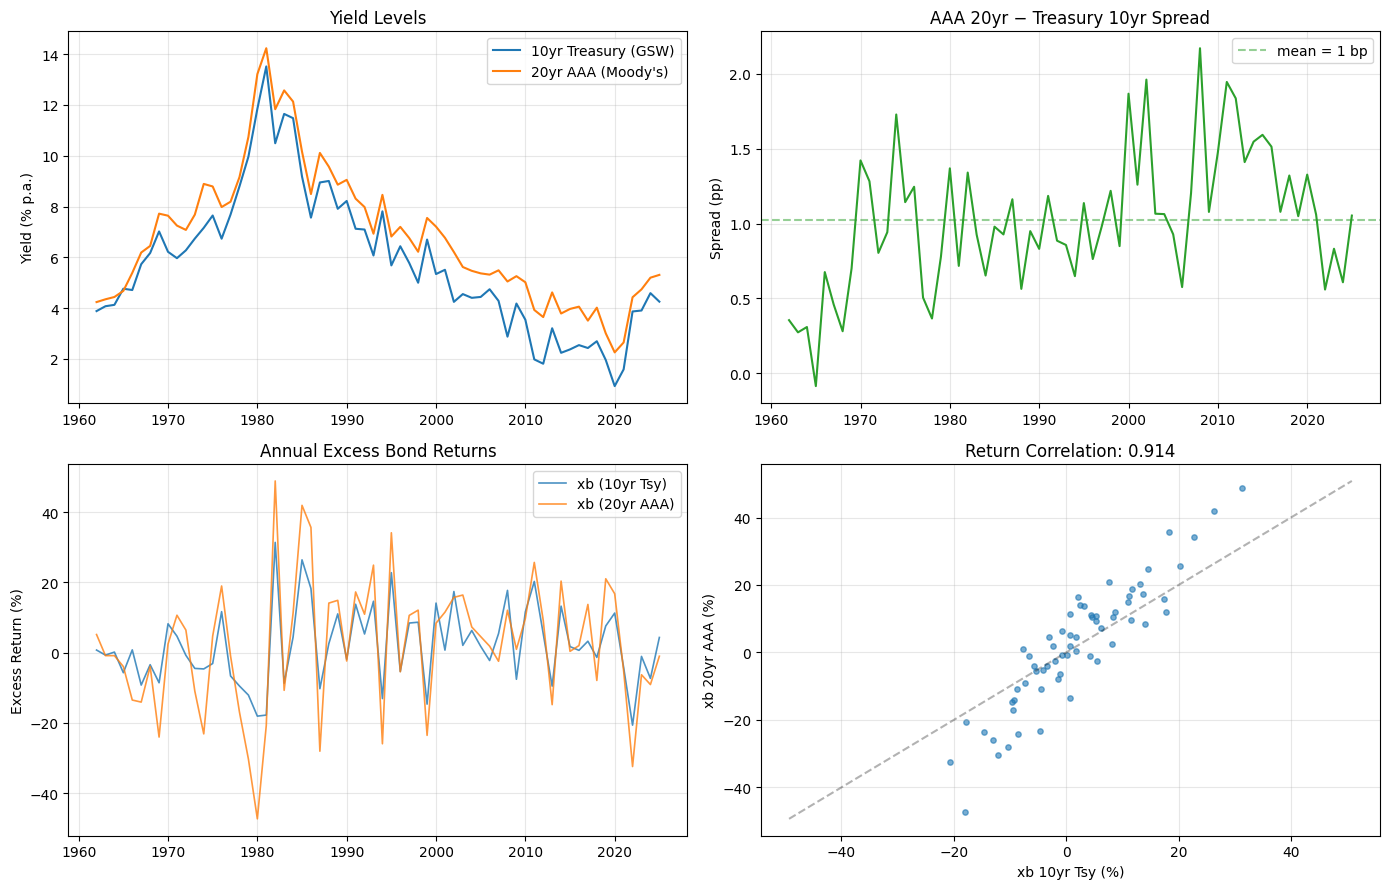

                          10yr Tsy      20yr AAA
------------------------------------------------
mean xb                     0.0195        0.0210
std xb                      0.1093        0.1826
mean yield                  0.0578        0.0680
std yield                   0.0275        0.0266
corr(xb)                    0.9141


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Yields
ax = axes[0, 0]
ax.plot(base_trim.index, base_trim["y_nom"] * 100, label="10yr Treasury (GSW)", lw=1.5)
ax.plot(alt.index, alt["y_nom"] * 100, label="20yr AAA (Moody's)", lw=1.5)
ax.set_ylabel("Yield (% p.a.)")
ax.set_title("Yield Levels")
ax.legend()
ax.grid(alpha=0.3)

# Yield spread
ax = axes[0, 1]
spread = (alt["y_nom"] - base_trim["y_nom"]) * 100
ax.plot(alt.index, spread, color="C2", lw=1.5)
ax.axhline(spread.mean(), color="C2", ls="--", alpha=0.5, label=f"mean = {spread.mean():.0f} bp")
ax.set_ylabel("Spread (pp)")
ax.set_title("AAA 20yr − Treasury 10yr Spread")
ax.legend()
ax.grid(alpha=0.3)

# Excess bond returns
ax = axes[1, 0]
ax.plot(base_trim.index, base_trim["xb"] * 100, label="xb (10yr Tsy)", alpha=0.8, lw=1.2)
ax.plot(alt.index, alt["xb"] * 100, label="xb (20yr AAA)", alpha=0.8, lw=1.2)
ax.set_ylabel("Excess Return (%)")
ax.set_title("Annual Excess Bond Returns")
ax.legend()
ax.grid(alpha=0.3)

# Return comparison scatter
ax = axes[1, 1]
ax.scatter(base_trim["xb"] * 100, alt["xb"] * 100, s=15, alpha=0.6)
mn = min(base_trim["xb"].min(), alt["xb"].min()) * 100 - 2
mx = max(base_trim["xb"].max(), alt["xb"].max()) * 100 + 2
ax.plot([mn, mx], [mn, mx], "k--", alpha=0.3)
corr = base_trim["xb"].corr(alt["xb"])
ax.set_xlabel("xb 10yr Tsy (%)")
ax.set_ylabel("xb 20yr AAA (%)")
ax.set_title(f"Return Correlation: {corr:.3f}")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats comparison
print(f"{'':20s}  {'10yr Tsy':>12s}  {'20yr AAA':>12s}")
print("-" * 48)
for stat, fn in [("mean xb", lambda d: d["xb"].mean()),
                 ("std xb", lambda d: d["xb"].std()),
                 ("mean yield", lambda d: d["y_nom"].mean()),
                 ("std yield", lambda d: d["y_nom"].std())]:
    print(f"{stat:20s}  {fn(base_trim):12.4f}  {fn(alt):12.4f}")
print(f"{'corr(xb)':20s}  {corr:12.4f}")

## 4. Estimate Restricted VAR(1) — Both Systems

Same specification: `[rtb, xr, xb, y_nom, dp]`, states = `[rtb, y_nom, dp]`, returns = `[xr, xb]`.

Only difference is the bond column: 10yr Treasury vs 20yr AAA.

In [4]:
def estimate_restricted_var1(data, columns, state_indices):
    """Restricted VAR(1): only lagged state variables enter each equation."""
    n = len(columns)
    state_cols = [columns[i] for i in state_indices]
    
    Y = data[columns].iloc[1:].to_numpy()
    X_state = data[state_cols].iloc[:-1].to_numpy()
    T_eff = Y.shape[0]
    X = np.column_stack([np.ones(T_eff), X_state])
    
    coeffs, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    Y_hat = X @ coeffs
    resid = Y - Y_hat
    dof = T_eff - X.shape[1]
    Omega = (resid.T @ resid) / dof
    
    const = coeffs[0, :]
    slope_mat = coeffs[1:, :]
    Phi = np.zeros((n, n))
    for k, j in enumerate(state_indices):
        Phi[:, j] = slope_mat[k, :]
    
    z_bar = data[columns].mean().to_numpy()
    const_ccv = (np.eye(n) - Phi) @ z_bar
    
    # R2
    r2 = {}
    for i, col in enumerate(columns):
        ss_res = np.sum((Y[:, i] - Y_hat[:, i])**2)
        ss_tot = np.sum((Y[:, i] - Y[:, i].mean())**2)
        r2[col] = 1 - ss_res / max(ss_tot, 1e-14)
    
    # Residual correlation
    D_inv = np.diag(1.0 / np.sqrt(np.maximum(np.diag(Omega), 1e-14)))
    corr = D_inv @ Omega @ D_inv
    
    return {
        "Phi": Phi, "Omega": Omega, "z_bar": z_bar, "const": const_ccv,
        "r2": r2, "resid_corr": corr, "resid": resid, "T_eff": T_eff,
        "columns": columns, "state_indices": state_indices,
    }

columns = ["rtb", "xr", "xb", "y_nom", "dp"]
state_idx = [0, 3, 4]  # rtb, y_nom, dp
ret_idx = [1, 2]        # xr, xb

est_base = estimate_restricted_var1(base_trim, columns, state_idx)
est_alt  = estimate_restricted_var1(alt, columns, state_idx)

print(f"Baseline (10yr Tsy):  T={est_base['T_eff']}")
print(f"Alternative (20yr AAA): T={est_alt['T_eff']}")

Baseline (10yr Tsy):  T=63
Alternative (20yr AAA): T=63


## 5. Compare VAR Parameters

In [5]:
def print_var_comparison(est1, est2, label1="10yr Tsy", label2="20yr AAA"):
    cols = est1["columns"]
    n = len(cols)
    s_idx = np.array(est1["state_indices"])
    r_idx = np.array([i for i in range(n) if i not in s_idx])
    state_names = [cols[i] for i in s_idx]
    ret_names = [cols[i] for i in r_idx]
    
    # ── Phi comparison ──
    print("=" * 72)
    print("PHI (TRANSITION MATRIX)")
    print("=" * 72)
    for label, est in [(label1, est1), (label2, est2)]:
        print(f"\n  {label}:")
        print(pd.DataFrame(est["Phi"], index=cols, columns=cols).round(4).to_string())
    
    print(f"\n  Difference ({label2} − {label1}):")
    diff = est2["Phi"] - est1["Phi"]
    print(pd.DataFrame(diff, index=cols, columns=cols).round(4).to_string())
    
    # ── State persistence ──
    print("\n" + "=" * 72)
    print("STATE PERSISTENCE (Phi diagonal)")
    print("=" * 72)
    print(f"  {'':8s}  {label1:>12s}  {label2:>12s}  {'Diff':>8s}")
    for i in s_idx:
        d1 = est1["Phi"][i, i]
        d2 = est2["Phi"][i, i]
        print(f"  {cols[i]:8s}  {d1:+12.4f}  {d2:+12.4f}  {d2-d1:+8.4f}")
    
    # ── Eigenvalues ──
    for label, est in [(label1, est1), (label2, est2)]:
        Phi_11 = est["Phi"][np.ix_(s_idx, s_idx)]
        eigs = np.sort(np.abs(np.linalg.eigvals(Phi_11)))[::-1]
        print(f"  {label} Phi_11 eigenvalues: {eigs.round(4).tolist()}")
    
    # ── Omega comparison ──
    print("\n" + "=" * 72)
    print("OMEGA (INNOVATION COVARIANCE) — Standard Deviations")
    print("=" * 72)
    print(f"  {'':8s}  {label1:>12s}  {label2:>12s}  {'Ratio':>8s}")
    for i, col in enumerate(cols):
        s1 = np.sqrt(est1["Omega"][i, i])
        s2 = np.sqrt(est2["Omega"][i, i])
        print(f"  {col:8s}  {s1:12.4f}  {s2:12.4f}  {s2/s1:8.2f}x")
    
    # ── Residual correlations ──
    print("\n" + "=" * 72)
    print("RESIDUAL CORRELATIONS")
    print("=" * 72)
    for label, est in [(label1, est1), (label2, est2)]:
        print(f"\n  {label}:")
        print(pd.DataFrame(est["resid_corr"], index=cols, columns=cols).round(3).to_string())
    
    # ── Conditioning matrix M = Sigma_rs @ inv(Sigma_ss) ──
    print("\n" + "=" * 72)
    print("CONDITIONING MATRIX M = Sigma_rs @ inv(Sigma_ss)")
    print("=" * 72)
    for label, est in [(label1, est1), (label2, est2)]:
        Omega_rs = est["Omega"][np.ix_(r_idx, s_idx)]
        Omega_ss = est["Omega"][np.ix_(s_idx, s_idx)]
        M = Omega_rs @ np.linalg.inv(Omega_ss)
        print(f"\n  {label}:")
        print(pd.DataFrame(M, index=ret_names, columns=state_names).round(4).to_string())
        print(f"  M[xb, y_nom] = {M[1, 1]:.2f}  (expect ≈ −duration)")
    
    # ── Unconditional means ──
    print("\n" + "=" * 72)
    print("UNCONDITIONAL MEANS (z_bar = sample means)")
    print("=" * 72)
    print(f"  {'':8s}  {label1:>12s}  {label2:>12s}")
    for i, col in enumerate(cols):
        print(f"  {col:8s}  {est1['z_bar'][i]:+12.6f}  {est2['z_bar'][i]:+12.6f}")
    
    # ── R² ──
    print("\n" + "=" * 72)
    print("EQUATION R²")
    print("=" * 72)
    print(f"  {'':8s}  {label1:>12s}  {label2:>12s}")
    for col in cols:
        print(f"  {col:8s}  {est1['r2'][col]:12.4f}  {est2['r2'][col]:12.4f}")
    
    # ── Variance explained by conditioning ──
    print("\n" + "=" * 72)
    print("RETURN VARIANCE EXPLAINED BY STATE CONDITIONING")
    print("=" * 72)
    for label, est in [(label1, est1), (label2, est2)]:
        Omega_rr = est["Omega"][np.ix_(r_idx, r_idx)]
        Omega_rs = est["Omega"][np.ix_(r_idx, s_idx)]
        Omega_ss = est["Omega"][np.ix_(s_idx, s_idx)]
        Omega_sr = est["Omega"][np.ix_(s_idx, r_idx)]
        M = Omega_rs @ np.linalg.inv(Omega_ss)
        Sigma_cond = Omega_rr - M @ Omega_sr
        explained = 1.0 - np.diag(Sigma_cond) / np.diag(Omega_rr)
        print(f"  {label}:")
        for k, rn in enumerate(ret_names):
            print(f"    {rn}: {100*explained[k]:.1f}% explained  "
                  f"(unconditional std={np.sqrt(Omega_rr[k,k]):.4f}, "
                  f"conditional std={np.sqrt(Sigma_cond[k,k]):.4f})")

print_var_comparison(est_base, est_alt)

PHI (TRANSITION MATRIX)

  10yr Tsy:
          rtb   xr   xb   y_nom      dp
rtb    0.4318  0.0  0.0  0.5533 -0.0142
xr     0.9942  0.0  0.0 -2.5550  0.1322
xb     0.9499  0.0  0.0  1.1334 -0.0844
y_nom -0.0837  0.0  0.0  0.8713  0.0084
dp    -1.7363  0.0  0.0  2.0554  0.8744

  20yr AAA:
          rtb   xr   xb   y_nom      dp
rtb    0.4673  0.0  0.0  0.4972 -0.0109
xr     0.7736  0.0  0.0 -2.1431  0.1112
xb     1.8122  0.0  0.0  1.5549 -0.1092
y_nom -0.0911  0.0  0.0  0.9208  0.0053
dp    -1.4996  0.0  0.0  1.5640  0.8974

  Difference (20yr AAA − 10yr Tsy):
          rtb   xr   xb   y_nom      dp
rtb    0.0355  0.0  0.0 -0.0561  0.0033
xr    -0.2206  0.0  0.0  0.4119 -0.0210
xb     0.8623  0.0  0.0  0.4215 -0.0248
y_nom -0.0074  0.0  0.0  0.0495 -0.0031
dp     0.2366  0.0  0.0 -0.4914  0.0230

STATE PERSISTENCE (Phi diagonal)
                10yr Tsy      20yr AAA      Diff
  rtb            +0.4318       +0.4673   +0.0355
  y_nom          +0.8713       +0.9208   +0.0495
  dp        

## 6. Visual Parameter Comparison

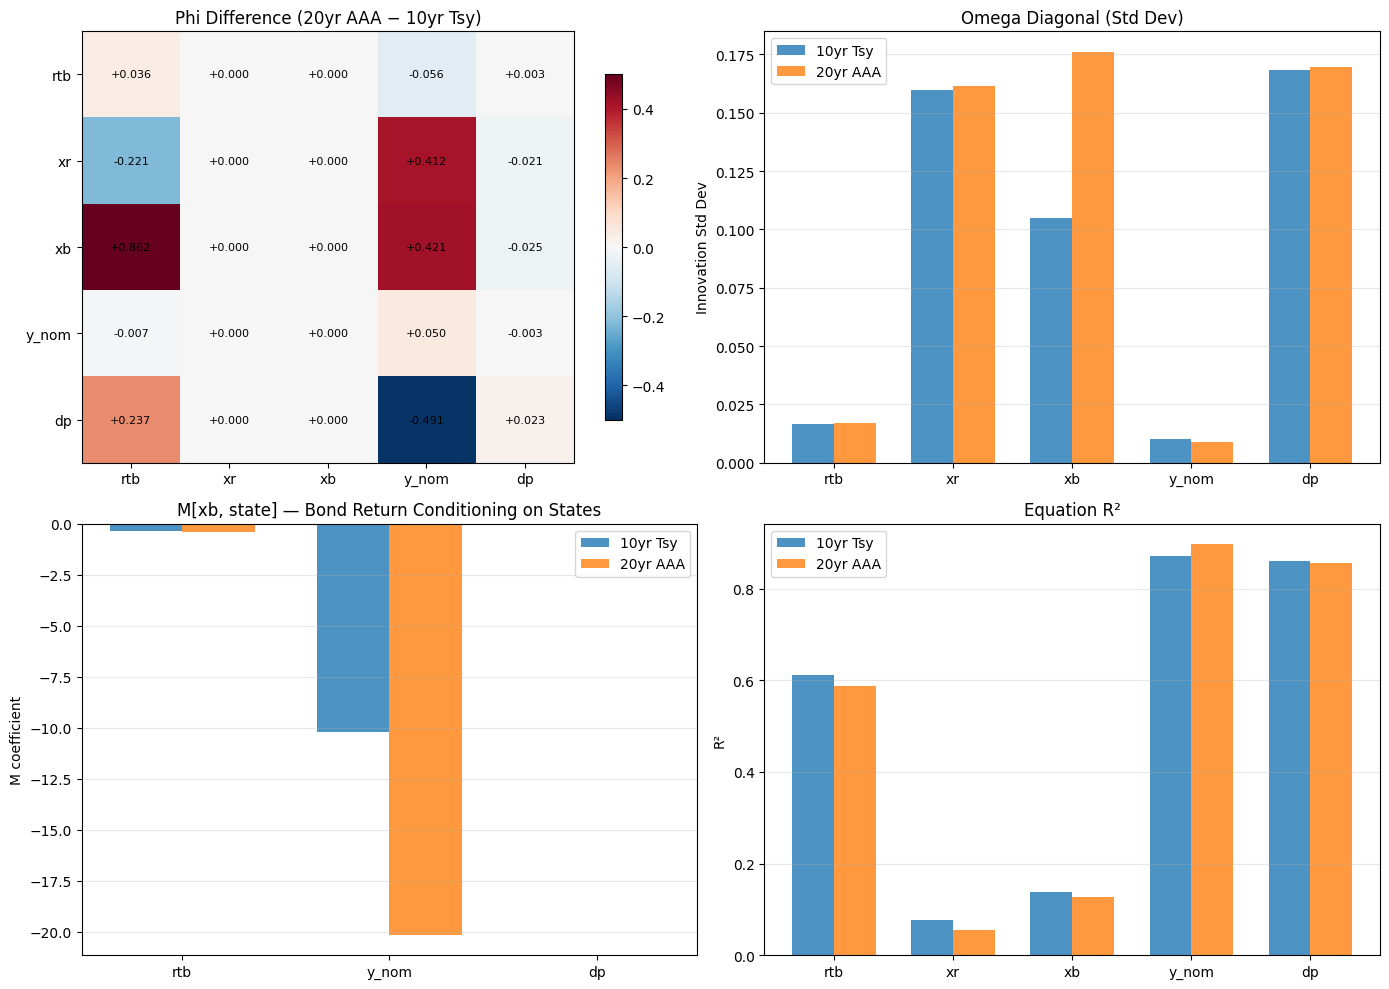

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cols = columns
s_idx = np.array(state_idx)
r_idx = np.array(ret_idx)
state_names = [cols[i] for i in s_idx]

# ── Phi heatmap difference ──
ax = axes[0, 0]
diff_phi = est_alt["Phi"] - est_base["Phi"]
im = ax.imshow(diff_phi, cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto")
ax.set_xticks(range(5)); ax.set_xticklabels(cols)
ax.set_yticks(range(5)); ax.set_yticklabels(cols)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{diff_phi[i,j]:+.3f}", ha="center", va="center", fontsize=8)
ax.set_title("Phi Difference (20yr AAA − 10yr Tsy)")
plt.colorbar(im, ax=ax, shrink=0.8)

# ── Omega std comparison ──
ax = axes[0, 1]
std_base = np.sqrt(np.diag(est_base["Omega"]))
std_alt  = np.sqrt(np.diag(est_alt["Omega"]))
x = np.arange(5)
w = 0.35
ax.bar(x - w/2, std_base, w, label="10yr Tsy", alpha=0.8)
ax.bar(x + w/2, std_alt, w, label="20yr AAA", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(cols)
ax.set_ylabel("Innovation Std Dev")
ax.set_title("Omega Diagonal (Std Dev)")
ax.legend()
ax.grid(alpha=0.3, axis="y")

# ── M[xb, :] conditioning coefficients ──
ax = axes[1, 0]
for label, est, offset, color in [("10yr Tsy", est_base, -w/2, "C0"), 
                                    ("20yr AAA", est_alt, w/2, "C1")]:
    Omega_rs = est["Omega"][np.ix_(r_idx, s_idx)]
    Omega_ss = est["Omega"][np.ix_(s_idx, s_idx)]
    M = Omega_rs @ np.linalg.inv(Omega_ss)
    ax.bar(np.arange(len(state_names)) + offset, M[1, :], w, 
           label=label, alpha=0.8, color=color)
ax.set_xticks(range(len(state_names))); ax.set_xticklabels(state_names)
ax.set_ylabel("M coefficient")
ax.set_title("M[xb, state] — Bond Return Conditioning on States")
ax.legend()
ax.grid(alpha=0.3, axis="y")

# ── R² comparison ──
ax = axes[1, 1]
r2_base = [est_base["r2"][c] for c in cols]
r2_alt  = [est_alt["r2"][c] for c in cols]
ax.bar(x - w/2, r2_base, w, label="10yr Tsy", alpha=0.8)
ax.bar(x + w/2, r2_alt, w, label="20yr AAA", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(cols)
ax.set_ylabel("R²")
ax.set_title("Equation R²")
ax.legend()
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 7. Implications for Portfolio Choice

Key differences that matter for the lifecycle model:
- **Duration exposure**: M[xb, y_nom] should scale roughly with duration (~10 vs ~20)
- **Bond return volatility**: 20yr bonds have ~2x the interest rate risk
- **Stock-bond correlation**: may differ due to credit spread component in AAA
- **Yield persistence**: AAA yield may have different AR(1) dynamics than Treasuries

In [7]:
# ── Key economic quantities side by side ──
print("=" * 72)
print("KEY PORTFOLIO-RELEVANT QUANTITIES")
print("=" * 72)

for label, est in [("10yr Tsy", est_base), ("20yr AAA", est_alt)]:
    print(f"\n{'─'*36}")
    print(f"  {label}")
    print(f"{'─'*36}")
    
    Phi = est["Phi"]
    Omega = est["Omega"]
    s = np.array(state_idx)
    r = np.array(ret_idx)
    
    Omega_rs = Omega[np.ix_(r, s)]
    Omega_ss = Omega[np.ix_(s, s)]
    Omega_rr = Omega[np.ix_(r, r)]
    Omega_sr = Omega[np.ix_(s, r)]
    M = Omega_rs @ np.linalg.inv(Omega_ss)
    Sigma_cond = Omega_rr - M @ Omega_sr
    
    print(f"  Mean xb:           {est['z_bar'][2]*100:+.2f}%")
    print(f"  Std xb:            {np.sqrt(Omega[2,2])*100:.2f}%")
    print(f"  Mean y_nom:        {est['z_bar'][3]*100:.2f}%")
    print(f"  Yield persistence: {Phi[3,3]:.4f}")
    print(f"  M[xb, y_nom]:      {M[1,1]:.2f}")
    print(f"  M[xb, rtb]:        {M[1,0]:.2f}")
    print(f"  M[xb, dp]:         {M[1,2]:.4f}")
    print(f"  Corr(xr, xb):      {Omega[1,2]/np.sqrt(Omega[1,1]*Omega[2,2]):.3f}")
    print(f"  Cond. std xb:      {np.sqrt(Sigma_cond[1,1])*100:.2f}%")
    print(f"  Sharpe (xb):       {est['z_bar'][2]/np.sqrt(Omega[2,2]):.3f}")

print(f"\n{'='*72}")
print("NOTES:")
print("  - M[xb, y_nom] ≈ −duration: measures bond price sensitivity to yield")
print("  - Larger |M| → more interest rate risk but also more hedging power")
print("  - AAA spread adds credit risk component not in Treasury returns")
print("=" * 72)

KEY PORTFOLIO-RELEVANT QUANTITIES

────────────────────────────────────
  10yr Tsy
────────────────────────────────────
  Mean xb:           +1.95%
  Std xb:            10.49%
  Mean y_nom:        5.78%
  Yield persistence: 0.8713
  M[xb, y_nom]:      -10.23
  M[xb, rtb]:        -0.37
  M[xb, dp]:         -0.0118
  Corr(xr, xb):      0.160
  Cond. std xb:      1.55%
  Sharpe (xb):       0.185

────────────────────────────────────
  20yr AAA
────────────────────────────────────
  Mean xb:           +2.10%
  Std xb:            17.61%
  Mean y_nom:        6.80%
  Yield persistence: 0.9208
  M[xb, y_nom]:      -20.15
  M[xb, rtb]:        -0.42
  M[xb, dp]:         -0.0080
  Corr(xr, xb):      0.336
  Cond. std xb:      1.23%
  Sharpe (xb):       0.119

NOTES:
  - M[xb, y_nom] ≈ −duration: measures bond price sensitivity to yield
  - Larger |M| → more interest rate risk but also more hedging power
  - AAA spread adds credit risk component not in Treasury returns
